<a href="https://colab.research.google.com/github/rg-smith/remote-sensing-hydro-2026/blob/main/lectures/lecture8-SWOT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SWOT Example

First, go to this website: https://code.earthengine.google.com/?scriptPath=users%2Fsat-io%2Fawesome-gee-catalog-examples%3Ahydrology%2FSWORD-NODES-REACHES-MERGED and identify a node ID using the identify tool in Earth Engine. You will use that node ID to generate a time series

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import requests

import datetime
from io import StringIO

In [2]:
# Assign URLs to Variables for the APIs we use, FTS and Hydrocron
FTS_URL = "https://fts.podaac.earthdata.nasa.gov/v1"
HYDROCRON_URL = "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries"

In [3]:
def query_hydrocron(query_url, node_id, start_time, end_time, fields, empty_df):
    """Query Hydrocron for reach-level time series data.

    Parameters
    ----------
    query_url: str - URL to use to query FTS
    reach_id: str - String SWORD reach identifier
    start_time: str - String time to start query
    end_time: str - String time to end query
    fields: list - List of fields to return in query response
    empty_df: pandas.DataFrame that contains empty query results

    Returns
    -------
    pandas.DataFrame that contains query results
    """

    params = {
        "feature": "Node",
        "feature_id": node_id,
        "output": "csv",
        "start_time": start_time,
        "end_time": end_time,
        "fields": fields
    }
    results = requests.get(query_url, params=params)
    if "results" in results.json().keys():
        results_csv = results.json()["results"]["csv"]
        df = pd.read_csv(StringIO(results_csv))
    else:
        df = empty_df

    return df

In [4]:
# Create queries that return Pandas.DataFrame objects
start_time = "2023-07-28T00:00:00Z"
end_time = "2026-02-16T00:00:00Z"
fields = "node_id,time_str,wse"

node = '74270900020361'
empty_df = pd.DataFrame({
    "node_id": np.int64(node),
    "time_str": datetime.datetime(1900, 1, 1).strftime("%Y-%m-%dT%H:%M:%S"),
    "wse": -999999999999.0,
    "wse_units": "m"
}, index=[0])
ts = query_hydrocron(HYDROCRON_URL, node, start_time, end_time, fields, empty_df)
print(ts)


           node_id              time_str           wse wse_units
0   74270900020361  2023-07-29T11:23:23Z  1.126878e+02         m
1   74270900020361               no_data -1.000000e+12         m
2   74270900020361  2023-09-09T04:53:34Z  1.124499e+02         m
3   74270900020361  2023-09-29T12:24:22Z  1.133331e+02         m
4   74270900020361  2023-09-30T01:38:37Z  1.134213e+02         m
5   74270900020361  2023-10-20T09:09:26Z  1.133614e+02         m
6   74270900020361  2023-10-20T22:23:41Z  1.135252e+02         m
7   74270900020361  2023-11-10T05:54:31Z  1.136571e+02         m
8   74270900020361  2023-11-10T19:08:47Z  1.319122e+02         m
9   74270900020361  2023-12-01T02:39:36Z  1.184017e+02         m
10  74270900020361  2023-12-01T15:53:52Z  1.132586e+02         m
11  74270900020361  2023-12-21T23:24:40Z  1.118854e+02         m
12  74270900020361  2023-12-22T12:38:56Z  1.122881e+02         m
13  74270900020361  2024-01-11T20:09:46Z  1.135374e+02         m
14  74270900020361  2024-

/tmp/ipykernel_177/283176332.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_good['time_str'] = pd.to_datetime(ts_good['time_str'])


Text(0, 0.5, 'Water Surface Elevation, m')

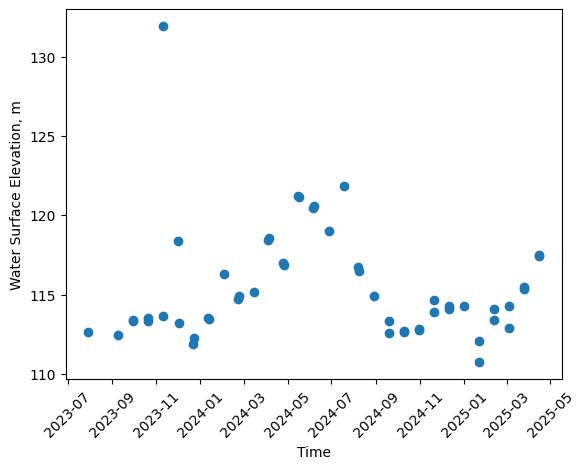

In [5]:
good_data = ts['wse']>0
ts_good = ts[good_data]
ts_good['time_str'] = pd.to_datetime(ts_good['time_str'])

plt.figure()
plt.plot(ts_good['time_str'][good_data], ts_good['wse'][good_data],'o')
# rotate xticks
plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Water Surface Elevation, m')